# LLM Fingerprinting — Exploration & Results Walkthrough

End-to-end walkthrough: raw generations → features → leak-free evaluation →
interpretability. Numbers here match `README.md`; this notebook exists to
show the reasoning and visuals behind them.

In [6]:
pip install pandas matplotlib seaborn shap jupyter tqdm joblib torch transformers

Defaulting to user installation because normal site-packages is not writeable
     -------------------------------------- 294.9/294.9 KB 2.3 MB/s eta 0:00:00
     -------------------------------------- 547.2/547.2 KB 3.8 MB/s eta 0:00:00
     ---------------------------------------- 80.2/80.2 KB 2.3 MB/s eta 0:00:00
     -------------------------------------- 309.1/309.1 KB 3.8 MB/s eta 0:00:00
     ---------------------------------------- 12.0/12.0 MB 4.3 MB/s eta 0:00:00
     ---------------------------------------- 2.7/2.7 MB 2.3 MB/s eta 0:00:00
     ---------------------------------------- 46.2/46.2 MB 2.0 MB/s eta 0:00:00
     ---------------------------------------- 11.2/11.2 MB 2.4 MB/s eta 0:00:00
     ---------------------------------------- 14.6/14.6 MB 1.9 MB/s eta 0:00:00
     -------------------------------------- 140.1/140.1 KB 2.1 MB/s eta 0:00:00
     ---------------------------------------- 12.5/12.5 MB 2.7 MB/s eta 0:00:00
     -------------------------------------- 

You should consider upgrading via the 'c:\Program Files (x86)\Microsoft Visual Studio\Shared\Python39_64\python.exe -m pip install --upgrade pip' command.


In [7]:
import json
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sys.path.append(str(Path.cwd().parent / "src"))

REPO_ROOT = Path.cwd().parent
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

MODEL_COLORS = {
    "llama3.2:3b": "#4C72B0",
    "phi3:mini": "#DD8452",
    "gemma2:2b": "#55A868",
    "mistral:7b-instruct-q4_0": "#C44E52",
}

## 1. Raw data overview

In [8]:
raw = pd.read_json(REPO_ROOT / "data" / "raw_generations.jsonl", lines=True)
print(f"Total generations: {len(raw)}")
print(f"Models: {raw['model'].nunique()}, Prompts: {raw['prompt_id'].nunique()}, "
      f"Categories: {raw['category'].nunique()}")
raw.groupby("model").size()

Total generations: 528
Models: 4, Prompts: 33, Categories: 6


model
gemma2:2b                   132
llama3.2:3b                 132
mistral:7b-instruct-q4_0    132
phi3:mini                   132
dtype: int64

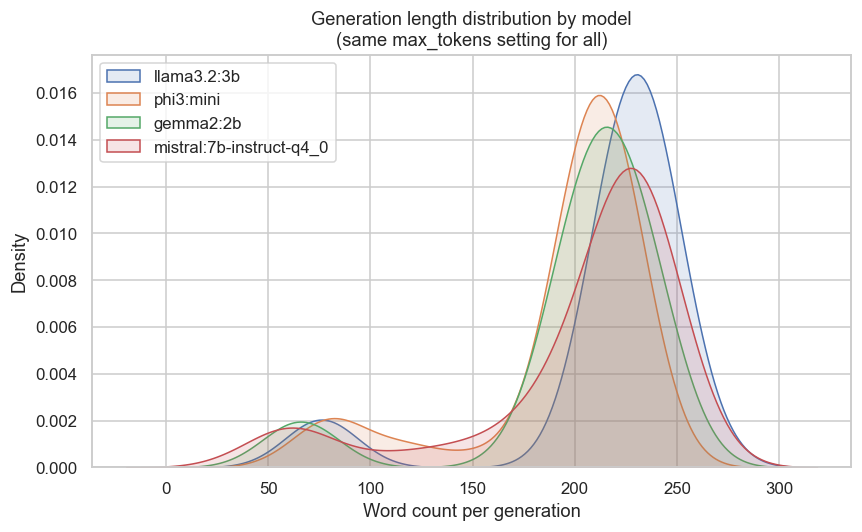

In [9]:
raw["word_count"] = raw["generated_text"].str.split().apply(len)

fig, ax = plt.subplots(figsize=(8, 5))
for model, color in MODEL_COLORS.items():
    subset = raw[raw["model"] == model]["word_count"]
    sns.kdeplot(subset, label=model, color=color, ax=ax, fill=True, alpha=0.15)
ax.set_xlabel("Word count per generation")
ax.set_title("Generation length distribution by model\n(same max_tokens setting for all)")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "results" / "figures" / "length_distribution.png")
plt.show()

In [10]:
category_balance = raw.groupby(["category", "model"]).size().unstack()
category_balance

model,gemma2:2b,llama3.2:3b,mistral:7b-instruct-q4_0,phi3:mini
category,,,,
creative,24,24,24,24
dialogue,24,24,24,24
factual,24,24,24,24
instructional,24,24,24,24
persuasive,24,24,24,24
summary,12,12,12,12


## 2. Feature matrix

Loading the final 528 × 199 feature matrix (195 features + 4 metadata columns).

In [11]:
features_df = pd.read_csv(REPO_ROOT / "data" / "features.csv")
print(f"Shape: {features_df.shape}")
metadata_cols = ["model", "prompt_id", "category", "gen_idx"]
feature_cols = [c for c in features_df.columns if c not in metadata_cols]
print(f"{len(feature_cols)} features across 3 signal families: "
      f"lexical/surface, syntactic (POS), predictability (perplexity)")
features_df.head(3)

Shape: (528, 199)
195 features across 3 signal families: lexical/surface, syntactic (POS), predictability (perplexity)


,model,prompt_id,category,gen_idx,avg_sentence_len,std_sentence_len,avg_word_len,total_words,punct_comma_per100w,punct_period_per100w,...,trigram_his,trigram_e i,trigram_ers,trigram_ we,"trigram_, a",trigram_.\n\n,trigram_ce,trigram_com,trigram_ur,perplexity
0,llama3.2:3b,fact_01,factual,0,17.176471,13.147289,5.366071,224,6.696429,7.142857,...,1.335113,6.008011,1.335113,0.000000,0.000000,0.667557,0.667557,0.000000,0.0,11.821481
1,llama3.2:3b,fact_01,factual,1,17.187500,12.768216,5.574879,207,3.864734,7.246377,...,1.396648,2.793296,0.000000,0.698324,0.000000,0.000000,0.698324,2.094972,0.0,12.947727
2,llama3.2:3b,fact_01,factual,2,18.066667,12.782627,5.684729,203,4.926108,6.896552,...,0.000000,4.884857,0.697837,0.697837,0.697837,0.000000,0.697837,0.697837,0.0,16.052040


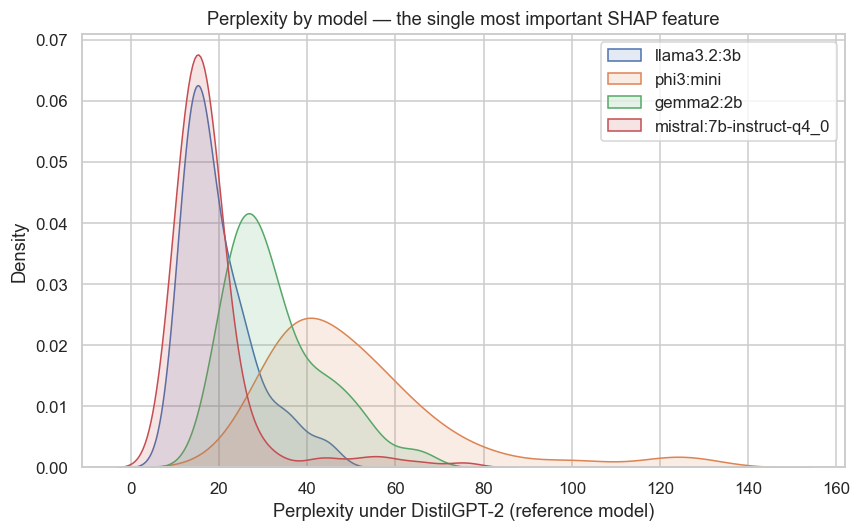

                           mean    std
model                                 
gemma2:2b                 32.92  11.17
llama3.2:3b               19.91   8.19
mistral:7b-instruct-q4_0  18.10  10.33
phi3:mini                 50.87  21.27


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
for model, color in MODEL_COLORS.items():
    subset = features_df[features_df["model"] == model]["perplexity"]
    sns.kdeplot(subset, label=model, color=color, ax=ax, fill=True, alpha=0.15)
ax.set_xlabel("Perplexity under DistilGPT-2 (reference model)")
ax.set_title("Perplexity by model — the single most important SHAP feature")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "results" / "figures" / "perplexity_distribution.png")
plt.show()

print(features_df.groupby("model")["perplexity"].agg(["mean", "std"]).round(2))

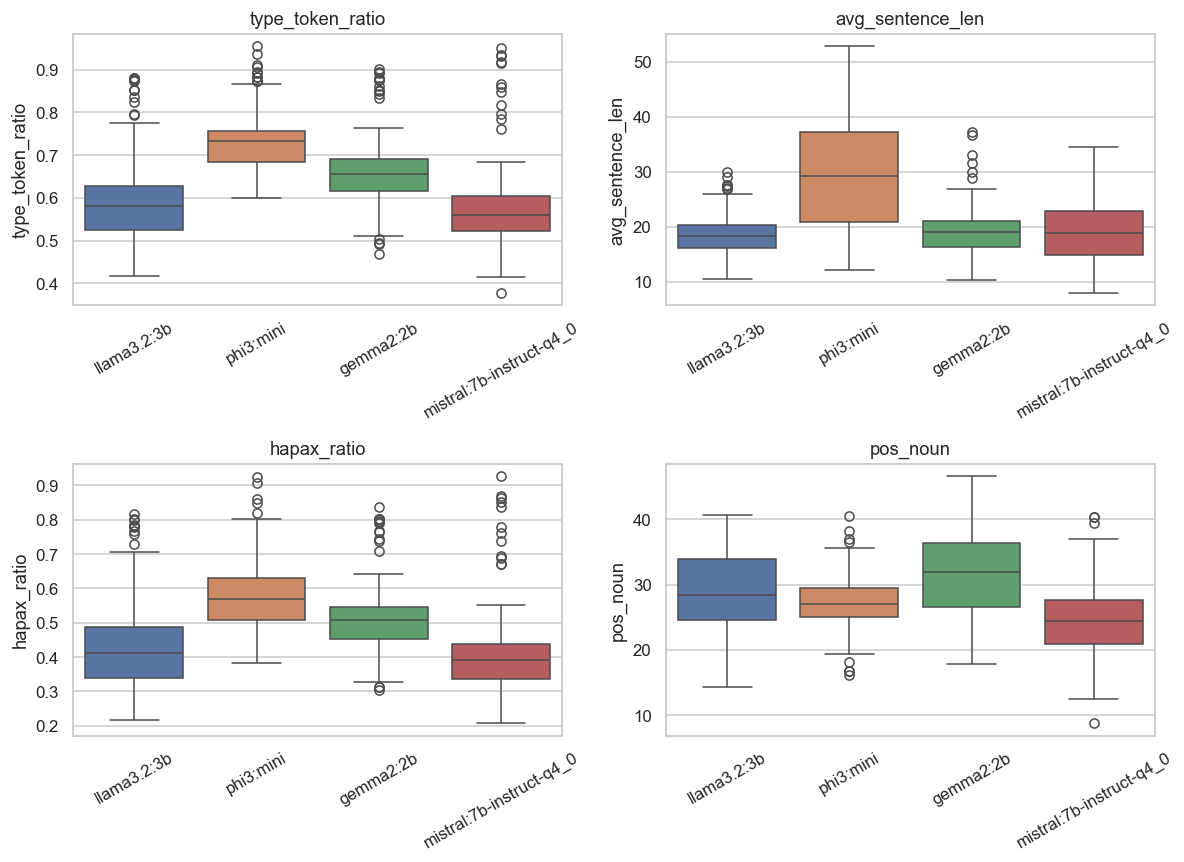

In [13]:
key_features = ["type_token_ratio", "avg_sentence_len", "hapax_ratio", "pos_noun"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feat in zip(axes.flat, key_features):
    sns.boxplot(data=features_df, x="model", y=feat, ax=ax,
                palette=MODEL_COLORS, hue="model", legend=False)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(REPO_ROOT / "results" / "figures" / "key_feature_boxplots.png")
plt.show()

## 3. Leak-free evaluation — quantifying the leakage gap

Comparing naive row-level splitting against prompt-level splitting on the
final feature set, to make the ~12-point inflation concrete rather than
just stating it.

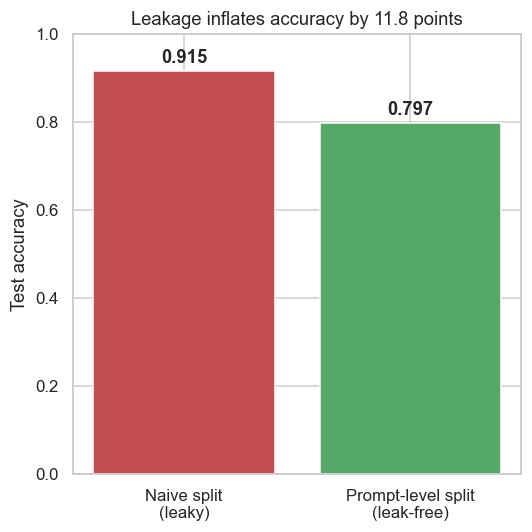

In [14]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

X = features_df[feature_cols]
y = features_df["model"]
groups = features_df["prompt_id"]

# naive (leaky) split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.22, random_state=42, stratify=y)
clf_leaky = RandomForestClassifier(n_estimators=300, random_state=42)
clf_leaky.fit(X_tr, y_tr)
leaky_acc = accuracy_score(y_te, clf_leaky.predict(X_te))

# prompt-level (leak-free) split
splitter = GroupShuffleSplit(n_splits=1, test_size=0.22, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

scaler = StandardScaler()
X_tr_pl = scaler.fit_transform(X.iloc[train_idx])
X_te_pl = scaler.transform(X.iloc[test_idx])
clf_clean = RandomForestClassifier(n_estimators=300, random_state=42)
clf_clean.fit(X_tr_pl, y.iloc[train_idx])
clean_acc = accuracy_score(y.iloc[test_idx], clf_clean.predict(X_te_pl))

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(["Naive split\n(leaky)", "Prompt-level split\n(leak-free)"],
              [leaky_acc, clean_acc], color=["#C44E52", "#55A868"])
ax.set_ylim(0, 1)
ax.set_ylabel("Test accuracy")
ax.set_title(f"Leakage inflates accuracy by {(leaky_acc - clean_acc)*100:.1f} points")
for bar, val in zip(bars, [leaky_acc, clean_acc]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}",
            ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(REPO_ROOT / "results" / "figures" / "leakage_comparison.png")
plt.show()

## 4. Final model: confusion matrix and per-class performance

Loading the saved model from `train.py` (RF trained on the full leak-free
prompt-level split, 195 features).

C:\Users\theekshanaa\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.9.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\theekshanaa\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.9.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\theekshanaa\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator

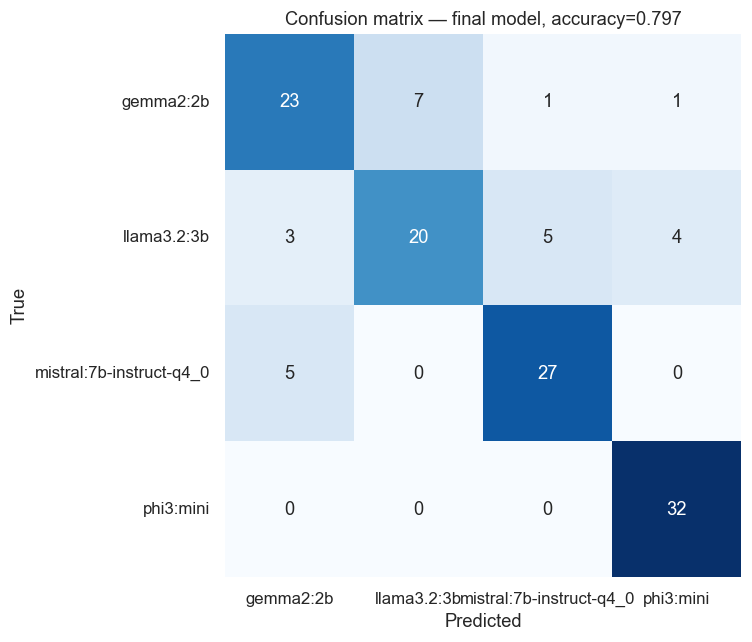

In [15]:
bundle = joblib.load(REPO_ROOT / "results" / "rf_model.joblib")
clf = bundle["model"]
scaler = bundle["scaler"]
feature_names = bundle["feature_names"]

from sklearn.model_selection import GroupShuffleSplit
splitter = GroupShuffleSplit(n_splits=1, test_size=0.22, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_test = X.iloc[test_idx][feature_names]
y_test = y.iloc[test_idx]
X_test_scaled = scaler.transform(X_test)

preds = clf.predict(X_test_scaled)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, preds, labels=sorted(y.unique()))
labels = sorted(y.unique())

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels,
            yticklabels=labels, ax=ax, cbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — final model, accuracy={accuracy_score(y_test, preds):.3f}")
plt.tight_layout()
plt.savefig(REPO_ROOT / "results" / "figures" / "confusion_matrix.png")
plt.show()

## 5. Why Llama is the hardest class — feature overlap visualized

SHAP identified Llama as sitting *between* Gemma2 and Mistral on nearly
every top feature rather than having a distinct signature. Visualizing that
directly.

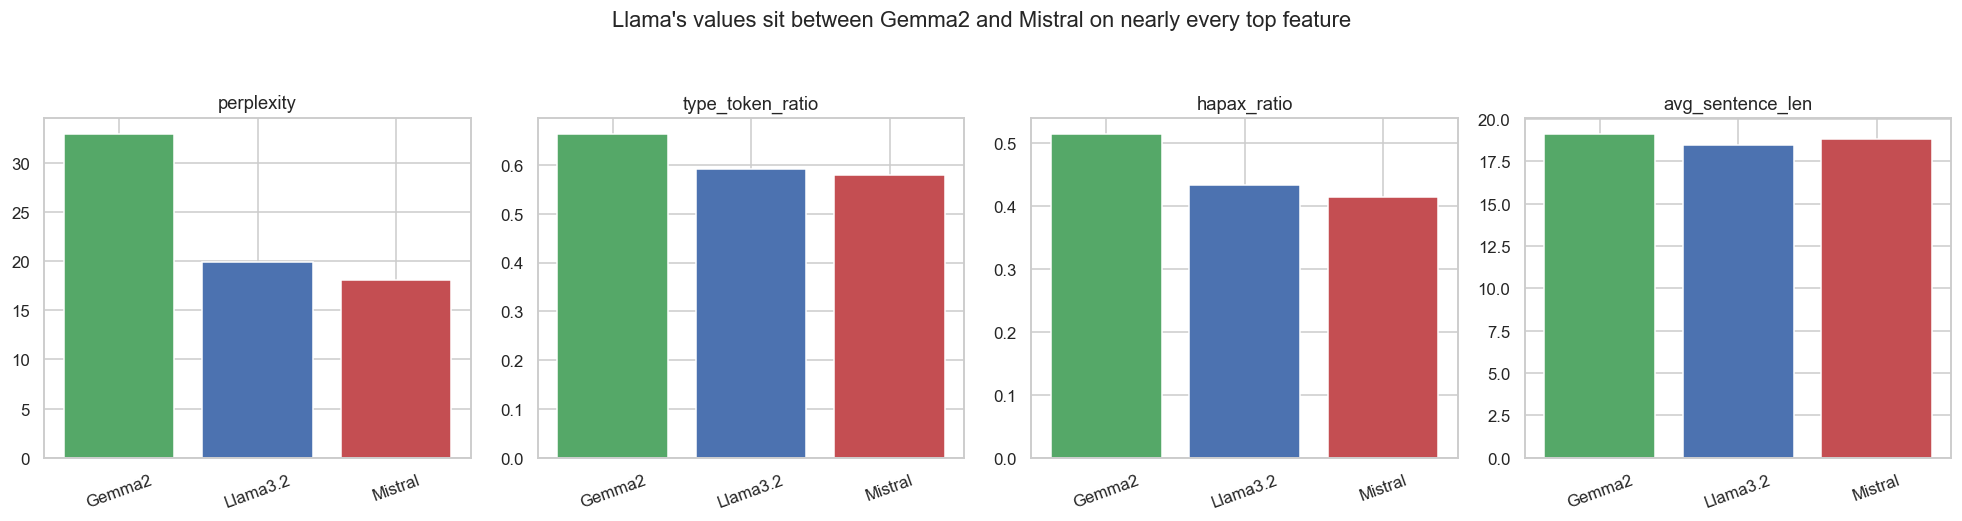

In [17]:
compare_models = ["gemma2:2b", "llama3.2:3b", "mistral:7b-instruct-q4_0"]
compare_features = ["perplexity", "type_token_ratio", "hapax_ratio", "avg_sentence_len"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, feat in zip(axes, compare_features):
    subset = features_df[features_df["model"].isin(compare_models)]
    means = subset.groupby("model")[feat].mean().reindex(compare_models)
    colors = [MODEL_COLORS[m] for m in compare_models]
    ax.bar(range(3), means.values, color=colors)
    ax.set_xticks(range(3))
    ax.set_xticklabels(["Gemma2", "Llama3.2", "Mistral"], rotation=20)
    ax.set_title(feat)
fig.suptitle("Llama's values sit between Gemma2 and Mistral on nearly every top feature", y=1.05)
plt.tight_layout()
plt.savefig(REPO_ROOT / "results" / "figures" / "llama_overlap.png")
plt.show()

## 6. Summary

- Prompt-level leak-free accuracy: **79.7%** (vs 91.5% naive/leaky — a
  ~12pt inflation from leakage alone)
- Grouped 5-fold CV: **85.7% ± 3.1%**
- Perplexity under a reference LM is the single most important feature
  (~1.6x the next-highest), validating the improvement pass mechanistically
- Phi-3 mini is perfectly separable (100% recall) — most distinct fingerprint
- Llama 3.2 is the hardest class (62% recall) because its style genuinely
  overlaps with Gemma2/Mistral rather than having a distinct signature —
  a finding, not a bug

See `README.md` for full writeup, limitations, and SHAP feature importance
details.